## Laboratorium 4

### Cel ćwiczenia
Celem ćwiczenia jest zastosowanie metody selekcji cech w klasyfikacji liści, a następnie przeprowadzenie klasyfikacji za pomocą klasyfikatora *k*NN.
Dodatkowo należy wyświetlić wyniki klasyfikacji w postaci macierzy pomyłek.

### Zbiór danych

Zbiór danych znajduje się w katalogu `dataset/*`. Jest to zmodyfikowany zbiór danych znajdujący się pod adresem: <https://archive.ics.uci.edu/ml/datasets/leaf>.

### Przesyłanie zadań

Wszystkie pliki należy spakować archiwizatorem **zip** i przesłać za pośrednictwem platformy WIKAMP. Poniżej oczekiwana zawartość archiwum:

```
+-- 📂 [IMIE.NAZWISKO].zip
    +-- 📜 Lab[xx].ipynb
    +-- 📂 dataset
        +-- 📜 dataset.npz
        +-- 📜 ReadMe.pdf
```



### Zadanie 1

* Wybierz 10 pierwszych gatunków liści (będziesz je używać w kolejnych zadaniach) o identyfikatorach: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10.
* Znormalizuj dane w zakresie 0-1.

### Zadanie 2
* Przeprowadź selekcję cech.
> Możesz wykorzystać bibliotekę [scikit-learn](https://scikit-learn.org/stable/modules/feature_selection.html) (np. [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html#sklearn.feature_selection.SelectKBest)).
* Dla każdej liczby cech (1-14) przeprowadz selekcje cech. Nastepnie wykonaj klasyfikacje klasyfikatorem *k*NN i znajdź optymalne *k*.
* Wyświetl wykres, gdzie na osi X znajduje się liczba cech, a na osi Y najwyższa osiągnięta dokładność (*accuracy*).
* Podaj dla jakiej liczby cech (i dla których cech) oraz dla jakiego *k* osiągnąłeś najlepszy wynik (*accuracy*).

### Zadanie 3
* Wyświetl tablicę pomyłek.

> Podpowiedź: Do wyświetlenia tablicy pomyłek możesz użyć funkcji [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) oraz [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) z biblioteki `sklearn`.

**Pamiętaj, wyniki powinny być czytelnie opisane oraz zaprezentowane graficznie (jeżeli jest taka możliwość).**

Przykład czego nie robić (na podstawie tablicy pomyłek):

**Źle** (kolumny ani wiersze nie są opisane):
```
array([[2, 0, 0],
       [0, 0, 1],
       [1, 0, 2]])
```



In [44]:
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import SelectKBest
from matplotlib import pyplot as plt

In [2]:
with open('./dataset/dataset.npz', 'rb') as f:
    data = np.load(f)
    train, test = data['train'], data['test']

In [4]:
train_df = pd.DataFrame(train)
test_df = pd.DataFrame(test)
train_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,36.0,1.0,0.390930,1.102500,0.733510,0.720220,0.694740,0.179540,0.076072,1.053200,0.059213,0.157470,0.024197,0.009541,0.000247,1.204200
1,5.0,4.0,0.936710,2.415100,0.729800,0.817930,0.864910,0.334390,0.080539,1.180500,0.048722,0.120510,0.014314,0.003998,0.000372,1.308300
2,29.0,1.0,0.837500,1.951200,0.490500,0.968000,0.982460,0.651380,0.016224,0.047908,0.005119,0.035621,0.001267,0.000322,0.000011,0.235140
3,35.0,3.0,0.907550,2.582000,0.623940,0.968370,0.998250,0.556740,0.031714,0.183050,0.079387,0.162130,0.025613,0.007412,0.000699,1.695100
4,32.0,7.0,0.884850,2.239800,0.557540,0.979970,0.998250,0.679740,0.009129,0.015166,0.025658,0.087206,0.007548,0.002152,0.000179,0.751540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,31.0,3.0,0.985425,12.367959,0.965230,0.802650,0.975840,0.043345,0.196795,7.280538,0.013304,0.035287,0.002212,0.000395,0.000086,0.316025
2240,29.0,6.0,0.732868,2.193675,0.451017,0.895804,0.917298,0.656747,0.030173,0.147090,0.012712,0.048700,0.000179,0.000484,-0.000019,0.363004
2241,12.0,8.0,0.972539,2.580435,0.604563,0.943933,0.927550,0.412375,0.027216,0.261505,0.093553,0.169002,0.032028,0.010133,0.000466,2.262180
2242,28.0,11.0,0.869988,2.412292,0.474942,0.894748,1.136941,0.723794,0.003889,0.034966,0.113536,0.209715,0.040135,0.010886,0.001081,2.261769


### Zadanie 1

* Wybierz 10 pierwszych gatunków liści (będziesz je używać w kolejnych zadaniach) o identyfikatorach: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10.
* Znormalizuj dane w zakresie 0-1.

In [9]:
train_df = train_df[train_df[0].isin([1,2,3,4,5,6,7,8,9,10])]
test_df = test_df[test_df[0].isin([1,2,3,4,5,6,7,8,9,10])]
sorted(train_df[0].unique()), sorted(test_df[0].unique())

([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
 [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])

In [26]:
scaler = MinMaxScaler(feature_range=(0, 1))

y_train = train_df[0]
y_test = test_df[0]

X_train = scaler.fit_transform(train_df.drop(columns=[0,1]))
X_test = scaler.transform(test_df.drop(columns=[0,1]))

X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)

X_train
# X_test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,0.812929,0.285190,0.760789,0.456157,0.655465,0.253757,0.521825,0.301404,0.248404,0.358640,0.198125,0.176083,0.132496,0.436743
1,0.780136,0.236464,0.718393,0.439192,0.640113,0.222252,0.305989,0.115550,0.201569,0.301460,0.153835,0.131909,0.106512,0.380794
2,0.697993,0.195389,0.433616,0.774175,0.824344,0.812135,0.029699,0.018849,0.319473,0.402736,0.236168,0.194220,0.226194,0.566962
3,0.455711,0.093843,0.608325,0.368456,0.350609,0.131624,0.806224,0.694068,0.130843,0.268081,0.130651,0.153039,0.026378,0.226562
4,0.367134,0.063170,0.294595,0.590641,0.822157,0.629566,0.213250,0.065409,0.135437,0.304144,0.155790,0.202109,0.026536,0.179253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
666,0.147214,0.019552,0.200415,0.458095,0.900911,0.767548,0.363826,0.121337,0.654439,0.884288,0.756486,0.922935,0.310023,0.679616
667,0.389486,0.054705,0.276864,0.649993,0.647763,0.509315,0.263619,0.124580,0.414446,0.571298,0.431799,0.378737,0.273915,0.555455
668,0.685662,0.228380,0.515926,0.529774,0.692451,0.536520,0.217719,0.062356,0.222705,0.375893,0.218193,0.221673,0.049544,0.300446
669,0.492241,0.053278,0.263347,0.662690,0.723508,0.624596,0.155608,0.056627,0.300484,0.458530,0.365614,0.451893,0.062697,0.326891


### Zadanie 2
* Przeprowadź selekcję cech.
> Możesz wykorzystać bibliotekę [scikit-learn](https://scikit-learn.org/stable/modules/feature_selection.html) (np. [SelectKBest](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SelectKBest.html#sklearn.feature_selection.SelectKBest)).
* Dla każdej liczby cech (1-14) przeprowadz selekcje cech. Nastepnie wykonaj klasyfikacje klasyfikatorem *k*NN i znajdź optymalne *k*.
* Wyświetl wykres, gdzie na osi X znajduje się liczba cech, a na osi Y najwyższa osiągnięta dokładność (*accuracy*).
* Podaj dla jakiej liczby cech (i dla których cech) oraz dla jakiego *k* osiągnąłeś najlepszy wynik (*accuracy*).

In [40]:
result = []
for f in range(1,14):
    selector = SelectKBest(k=f)
    X = selector.fit_transform(X_train, y_train)
    f_ = selector.get_feature_names_out(X_train.columns)

    best_k = None
    best_acc = 0
    
    for k in range(1,11):
        knn = KNeighborsClassifier(n_neighbors=k)
        knn.fit(X, y_train)
        y_pred = knn.predict(X_test[f_])

        res = [i==j for i,j in zip(y_test, y_pred)]

        acc = sum(res)/len(res)

        if acc > best_acc:
            best_acc = acc
            best_k = k

    result.append((f, best_k, best_acc, f_))


result_df = pd.DataFrame(result, columns=['f', 'k', 'acc', 'features'])
result_df

,f,k,acc,features
0,1,9,0.369439,[1]
1,2,10,0.705996,"[1, 6]"
2,3,6,0.709865,"[1, 6, 7]"
3,4,8,0.733075,"[1, 5, 6, 7]"
4,5,8,0.802708,"[1, 2, 5, 6, 7]"
5,6,7,0.808511,"[0, 1, 2, 5, 6, 7]"
6,7,10,0.750484,"[0, 1, 2, 5, 6, 7, 8]"
7,8,10,0.762089,"[0, 1, 2, 5, 6, 7, 8, 9]"
8,9,1,0.758221,"[0, 1, 2, 5, 6, 7, 8, 9, 10]"
9,10,4,0.758221,"[0, 1, 2, 5, 6, 7, 8, 9, 10, 13]"


In [46]:
best_acc = result_df['acc'].max()
best_k = result_df['k'][result_df['acc'].idxmax()]
best_f = result_df['f'][result_df['acc'].idxmax()]

print(f"Best accuracy: {best_acc} for f={best_f} and k={best_k}")

Best accuracy: 0.8085106382978723 for f=6 and k=7


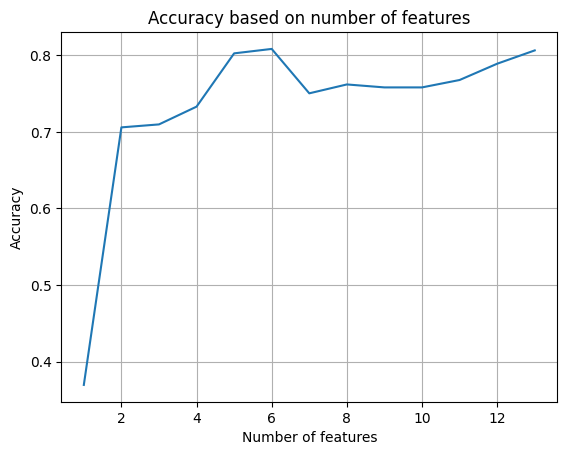

In [43]:
plt.plot(result_df['f'], result_df['acc'])
plt.xlabel('Number of features')
plt.ylabel('Accuracy')
plt.title('Accuracy based on number of features')
plt.grid()
plt.show()

### Zadanie 3
* Wyświetl tablicę pomyłek.

> Podpowiedź: Do wyświetlenia tablicy pomyłek możesz użyć funkcji [`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) oraz [`ConfusionMatrixDisplay`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html) z biblioteki `sklearn`.

**Pamiętaj, wyniki powinny być czytelnie opisane oraz zaprezentowane graficznie (jeżeli jest taka możliwość).**

Przykład czego nie robić (na podstawie tablicy pomyłek):

**Źle** (kolumny ani wiersze nie są opisane):
```
array([[2, 0, 0],
       [0, 0, 1],
       [1, 0, 2]])
```

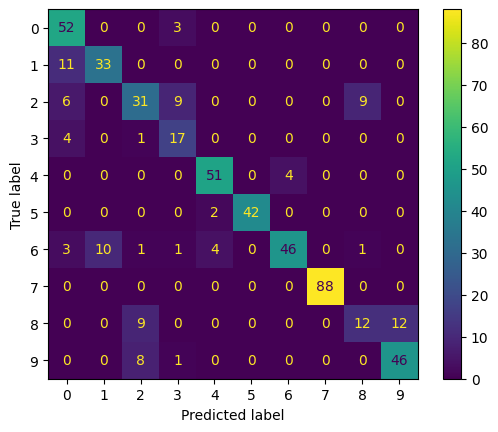

In [53]:
selector = SelectKBest(k=best_f)
X = selector.fit_transform(X_train, y_train)
f_ = selector.get_feature_names_out(X_train.columns)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X, y_train)
y_pred = knn.predict(X_test[f_])

res = [i==j for i,j in zip(y_test, y_pred)]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()